# Libs and config

In [87]:
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.ensemble import RandomForestClassifier
# from lightgbm import LGBMClassifier

from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    confusion_matrix_at_thresholds,
    roc_auc_score,
)

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split, TimeSeriesSplit
import pandas as pd
import numpy as np
import seaborn as sns
from dython.nominal import associations
from matplotlib import pyplot as plt

import os

os.chdir("..")

In [65]:
sns.set_palette("deep")

# Data

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("data/df_cleaned.csv")

display(df.head())

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Credit-Builder Loan,Auto Loan,Payday Loan,Mortgage Loan,Home Equity Loan,Student Loan,Debt Consolidation Loan,Not Specified,Personal Loan,Credit_Score_binomial
0,CUS_0x1000,202201,17,30625.94,2706.161667,6,27,2,62,1.63,10.0,1562.91,26.612093,10.166667,42.94109,244.750283,252.924793,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,1,0,0,0,1,0,0,0,0,0
1,CUS_0x1000,202202,17,30625.94,2706.161667,6,27,2,62,1.63,11.0,1562.91,29.439759,10.250000,42.94109,176.132567,311.542510,23.0,Lawyer,Bad,High_spent_Small_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
2,CUS_0x1000,202203,17,30625.94,2706.161667,6,27,2,62,1.63,11.0,1562.91,38.285928,10.333333,42.94109,109.056519,368.618557,28.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
3,CUS_0x1000,202204,17,30625.94,2706.161667,6,27,2,64,1.63,11.0,1562.91,32.843081,10.416667,42.94109,87.909909,419.765167,25.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
4,CUS_0x1000,202205,17,30625.94,2706.161667,6,27,2,67,2.63,11.0,1562.91,32.330508,10.500000,42.94109,191.834767,305.840309,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,1,0,0,0,1,0,0,0,0,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  str    
 1   num_month                 100000 non-null  int64  
 2   Age                       100000 non-null  int64  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  int64  
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  int64  
 8   Delay_from_due_date       100000 non-null  int64  
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      100000 non-null  float64
 11  Outstanding_Debt          100000 non-null  float64
 12  Credit_Utilization_Ratio  100000 non-null  float64
 13  Credit_History_Age        100000 non-null  float64
 14  

# Organazing columns

In [5]:
numeric_features = df.select_dtypes(include="number").columns.tolist()
numeric_features.remove("num_month")
print(len(numeric_features))
print(numeric_features)

categorical_features = df.select_dtypes(
    include=["object", "category", "bool", "str"]
).columns.tolist()

categorical_features.remove("Customer_ID")
print(len(categorical_features))
print(categorical_features)

keys = ["Customer_ID", "num_month"]
features_to_drop = []
keys

26
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment', 'Credit-Builder Loan', 'Auto Loan', 'Payday Loan', 'Mortgage Loan', 'Home Equity Loan', 'Student Loan', 'Debt Consolidation Loan', 'Not Specified', 'Personal Loan', 'Credit_Score_binomial']
4
['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']


['Customer_ID', 'num_month']

In [6]:
feature_summary = pd.DataFrame(
    {
        "dtype": df.dtypes,
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
    }
)

feature_summary.sort_values("n_unique").head(10)

,dtype,n_unique,missing,missing_pct
Payday Loan,int64,2,0,0.0
Mortgage Loan,int64,2,0,0.0
Home Equity Loan,int64,2,0,0.0
Student Loan,int64,2,0,0.0
Debt Consolidation Loan,int64,2,0,0.0
Credit_Score_binomial,int64,2,0,0.0
Not Specified,int64,2,0,0.0
Personal Loan,int64,2,0,0.0
Auto Loan,int64,2,0,0.0
Payment_of_Min_Amount,str,2,0,0.0


# Correlation matrix (default pearson pandas)

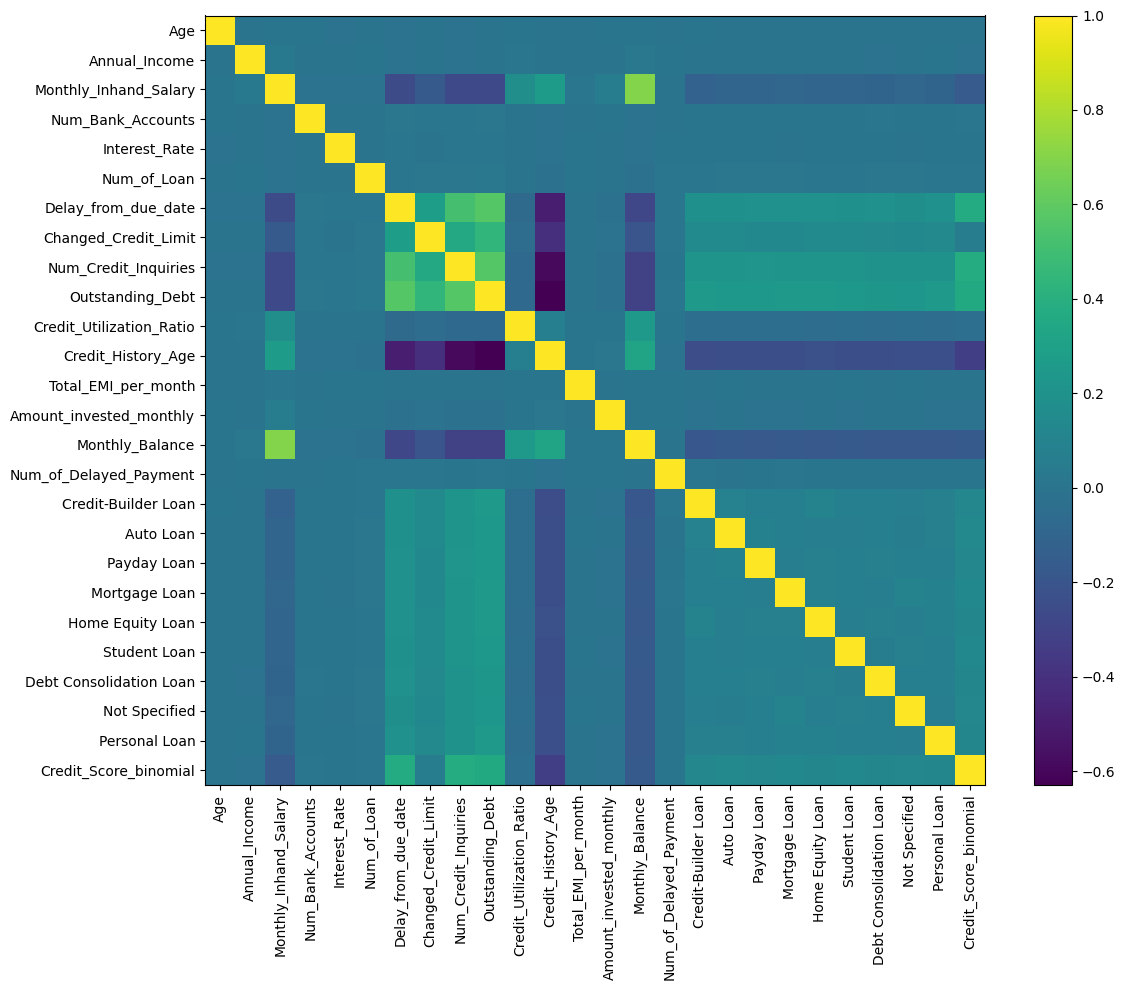

In [7]:
numeric_corr = df[numeric_features].corr(method="pearson")


plt.figure(figsize=(12, 10))
plt.imshow(numeric_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns, rotation=90)
plt.yticks(
    range(len(numeric_corr.columns)),
    numeric_corr.columns,
)

plt.tight_layout()

plt.show()

In [8]:
corr_matrix = df[numeric_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_paris = upper_triangle.stack().sort_values(ascending=False)

high_corr_paris.head(20)

Monthly_Inhand_Salary  Monthly_Balance          0.699620
Outstanding_Debt       Credit_History_Age       0.629317
Num_Credit_Inquiries   Credit_History_Age       0.587125
Delay_from_due_date    Outstanding_Debt         0.571713
Num_Credit_Inquiries   Outstanding_Debt         0.570953
Delay_from_due_date    Num_Credit_Inquiries     0.516462
                       Credit_History_Age       0.491183
Changed_Credit_Limit   Outstanding_Debt         0.443653
                       Credit_History_Age       0.411025
Num_Credit_Inquiries   Credit_Score_binomial    0.376396
Delay_from_due_date    Credit_Score_binomial    0.373089
Outstanding_Debt       Credit_Score_binomial    0.362518
Changed_Credit_Limit   Num_Credit_Inquiries     0.354354
Credit_History_Age     Credit_Score_binomial    0.327987
                       Monthly_Balance          0.323291
Outstanding_Debt       Monthly_Balance          0.316111
Num_Credit_Inquiries   Monthly_Balance          0.305700
Delay_from_due_date    Changed_

# Salaries 

In [9]:
df

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Credit-Builder Loan,Auto Loan,Payday Loan,Mortgage Loan,Home Equity Loan,Student Loan,Debt Consolidation Loan,Not Specified,Personal Loan,Credit_Score_binomial
0,CUS_0x1000,202201,17,30625.94,2706.161667,6,27,2,62,1.63,10.0,1562.91,26.612093,10.166667,42.941090,244.750283,252.924793,25.000000,Lawyer,Bad,Low_spent_Large_value_payments,Yes,1,0,0,0,1,0,0,0,0,0
1,CUS_0x1000,202202,17,30625.94,2706.161667,6,27,2,62,1.63,11.0,1562.91,29.439759,10.250000,42.941090,176.132567,311.542510,23.000000,Lawyer,Bad,High_spent_Small_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
2,CUS_0x1000,202203,17,30625.94,2706.161667,6,27,2,62,1.63,11.0,1562.91,38.285928,10.333333,42.941090,109.056519,368.618557,28.000000,Lawyer,Bad,High_spent_Medium_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
3,CUS_0x1000,202204,17,30625.94,2706.161667,6,27,2,64,1.63,11.0,1562.91,32.843081,10.416667,42.941090,87.909909,419.765167,25.000000,Lawyer,Bad,High_spent_Medium_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
4,CUS_0x1000,202205,17,30625.94,2706.161667,6,27,2,67,2.63,11.0,1562.91,32.330508,10.500000,42.941090,191.834767,305.840309,25.000000,Lawyer,Bad,Low_spent_Large_value_payments,Yes,1,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,CUS_0xffd,202204,29,41398.44,3749.870000,8,13,-100,19,10.07,7.0,1701.88,36.384516,18.416667,182.976649,234.354940,402.739948,12.000000,Scientist,Standard,High_spent_Medium_value_payments,Yes,0,1,1,1,1,0,0,0,0,0
99996,CUS_0xffd,202205,29,41398.44,3749.870000,8,13,6,23,10.07,7.0,1701.88,26.166508,18.500000,182.976649,104.629474,402.739948,11.428571,Scientist,Standard,High_spent_Medium_value_payments,Yes,0,1,1,1,1,0,0,0,0,0
99997,CUS_0xffd,202206,29,41398.44,3749.870000,8,13,6,23,10.07,7.0,1701.88,36.970072,18.583333,182.976649,47.007379,402.739948,12.000000,Scientist,Standard,High_spent_Medium_value_payments,Yes,0,1,1,1,1,0,0,0,0,0
99998,CUS_0xffd,202207,30,41398.44,3749.870000,8,13,6,23,10.07,7.0,1701.88,33.916363,18.666667,182.976649,257.989694,402.739948,12.000000,Scientist,Standard,High_spent_Small_value_payments,Yes,0,1,1,1,1,0,0,0,0,0


In [10]:
412.112083 * 12

4945.344996

In [11]:
df["anual_month_salary_ratio"] = df["Annual_Income"] / df["Monthly_Inhand_Salary"]
print(
    df["anual_month_salary_ratio"].describe(percentiles=[0.9, 0.95, 0.99, 0.995, 0.999])
)

(df["anual_month_salary_ratio"] > 21).mean()

count    100000.000000
mean         67.191730
std         834.982228
min           8.089821
90%          13.555580
95%          14.570633
99%          23.184098
99.5%      3318.080014
99.9%     13133.161038
max       54110.522117
Name: anual_month_salary_ratio, dtype: float64


np.float64(0.01062)

In [12]:
df[
    [
        "Customer_ID",
        "num_month",
        "Annual_Income",
        "Monthly_Inhand_Salary",
        "anual_month_salary_ratio",
        "Credit_Score_binomial",
    ]
].sort_values(by="anual_month_salary_ratio", ascending=False)

,Customer_ID,num_month,Annual_Income,Monthly_Inhand_Salary,anual_month_salary_ratio,Credit_Score_binomial
2470,CUS_0x14e5,202207,22299600.00,412.112083,54110.522117,0
42698,CUS_0x6079,202203,23393201.00,458.671250,51002.108809,1
39983,CUS_0x5bba,202208,23713472.00,512.003333,46315.073470,1
41183,CUS_0x5dfa,202208,23834698.00,684.157917,34838.006576,0
63674,CUS_0x8763,202203,19885293.00,589.001250,33761.037010,1
...,...,...,...,...,...,...
67353,CUS_0x8df6,202202,7174.99,886.915833,8.089821,0
67352,CUS_0x8df6,202201,7174.99,886.915833,8.089821,0
67359,CUS_0x8df6,202208,7174.99,886.915833,8.089821,0
67357,CUS_0x8df6,202206,7174.99,886.915833,8.089821,0


In [13]:
df[["Annual_Income", "Monthly_Inhand_Salary"]].corr(method="spearman")

,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.974706
Monthly_Inhand_Salary,0.974706,1.000000


In [14]:
df[df["anual_month_salary_ratio"] < 21][
    ["Annual_Income", "Monthly_Inhand_Salary"]
].corr(method="pearson")

,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.998202
Monthly_Inhand_Salary,0.998202,1.000000


In [15]:
features_to_drop += ["Monthly_Inhand_Salary"]
features_to_drop

['Monthly_Inhand_Salary']

# Num_Bank_Accounts

In [17]:
df["Num_Bank_Accounts"].describe()

count    100000.000000
mean         17.091280
std         117.404834
min          -1.000000
25%           3.000000
50%           6.000000
75%           7.000000
max        1798.000000
Name: Num_Bank_Accounts, dtype: float64

In [39]:
df_nonsense["Credit_Score_binomial"].mean()

np.float64(0.549535839293867)

In [45]:
p95 = df["Num_Bank_Accounts"].quantile(0.95)
print(p95)
df_nonsense = df[df["Num_Bank_Accounts"] >= p95]
print(df_nonsense.shape)

print(
    "Mean of bad creidt score in non sense values:",
    df_nonsense["Credit_Score_binomial"].mean(),
    "\nMean of bad creidt score in the entire data:",
    df["Credit_Score_binomial"].mean(),
)

10.0
(6571, 33)
Mean of bad creidt score in non sense values: 0.549535839293867 
Mean of bad creidt score in the entire data: 0.28998


In [84]:
df = df.sort_values(by="Num_Bank_Accounts_str")
df["Num_Bank_Accounts_str"] = np.where(
    df["Num_Bank_Accounts"] > 10, 10000, df["Num_Bank_Accounts"]
)

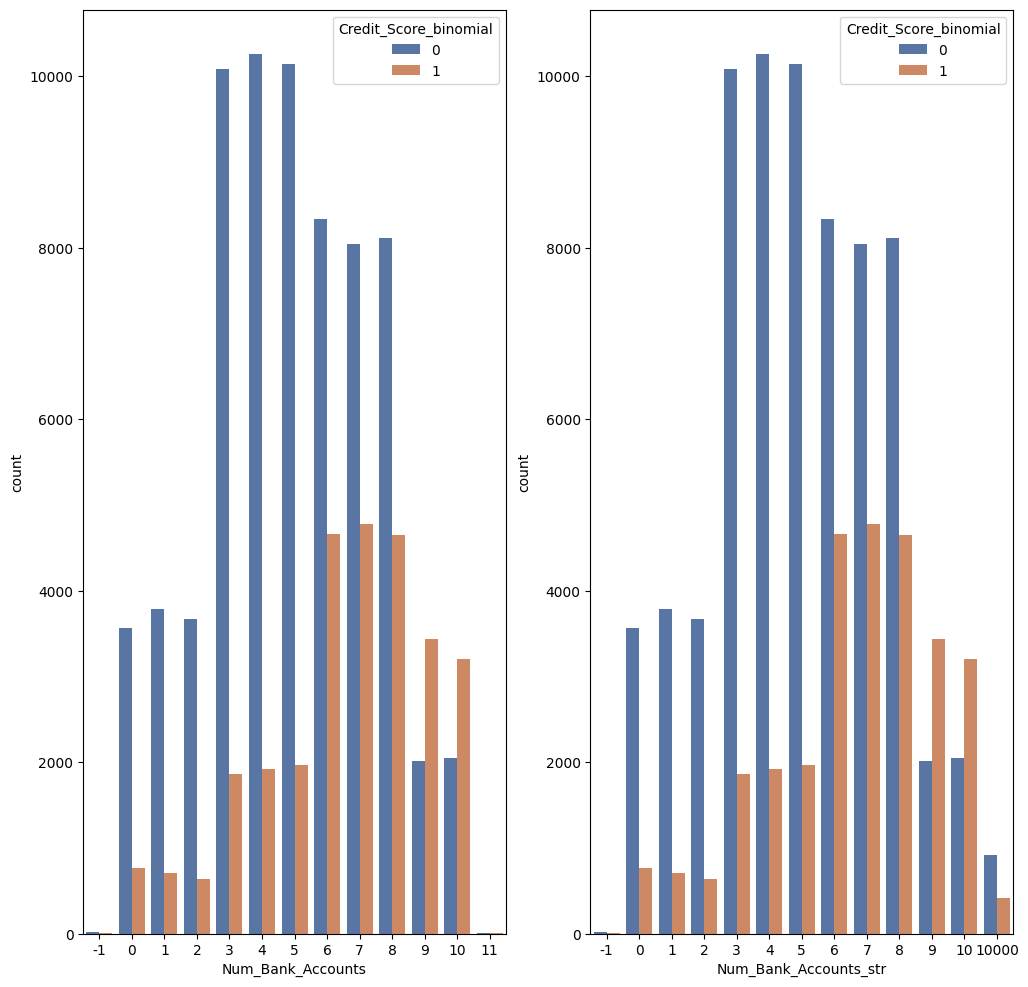

In [85]:
analysis = df["Num_Bank_Accounts"].value_counts().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 12))

sns.countplot(
    df[df["Num_Bank_Accounts"] <= 12],
    x="Num_Bank_Accounts",
    hue="Credit_Score_binomial",
    orient="h",
    ax=axes[0],
)


sns.countplot(
    df, x="Num_Bank_Accounts_str", hue="Credit_Score_binomial", orient="h", ax=axes[1]
)


plt.show()

In [ ]:
print(df["Num_Bank_Accounts"].corr(df["Credit_Score_binomial"], method="spearman"))
print(df["Num_Bank_Accounts"].corr(df["Credit_Score_binomial"], method="spearman"))

np.float64(0.28625951420488566)

In [91]:
df[numeric_features]

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Credit-Builder Loan,Auto Loan,Payday Loan,Mortgage Loan,Home Equity Loan,Student Loan,Debt Consolidation Loan,Not Specified,Personal Loan,Credit_Score_binomial
81633,54,117851.07,9870.922500,-1,7,0,27,4.97,1.0,607.78,37.286105,20.500000,0.000000,668.144454,588.947796,1.000000,0,0,0,0,0,0,0,0,0,1
38797,40,30352.11,2317.342500,-1,7,-100,8,5.11,0.0,644.57,31.813259,23.833333,16.483566,54.821327,400.429357,3.000000,0,0,0,0,0,1,0,0,0,0
38799,41,30352.11,2317.342500,-1,7,1,8,7.11,0.0,644.57,32.937399,24.000000,16.483566,89.622962,375.627721,4.000000,0,0,0,0,0,1,0,0,0,0
81637,54,117851.07,9870.922500,-1,7,0,22,4.97,1.0,607.78,32.303737,20.833333,0.000000,218.005223,1019.087027,1.000000,0,0,0,0,0,0,0,0,0,1
81634,54,117851.07,9870.922500,-1,7,0,27,0.97,1.0,607.78,41.915627,20.583333,0.000000,142.319789,1084.772461,1.000000,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82220,24,18735.98,1776.331667,1096,20,3,22,9.54,9.0,1505.00,26.540324,9.750000,37.328142,72.732431,357.572593,17.000000,0,1,0,0,1,0,1,0,0,1
25700,19,27323.11,2111.925833,1456,10,2,6,7.17,5.0,1202.40,36.051774,12.000000,28.357625,81.913556,360.921403,9.428571,1,0,0,0,1,0,0,0,0,0
78209,25,66376.28,5723.356667,1668,15,3,29,0.00,3.0,1482.30,42.456986,32.916667,104.631775,155.127887,582.576004,12.000000,0,1,1,0,1,0,0,0,0,0
52299,43,14258646.00,1244.853750,705,10,3,6,11.92,7.0,495.74,22.122918,26.083333,37.445859,23.202988,303.836528,12.000000,0,0,0,0,1,0,0,1,1,0


In [112]:
associations = []
for feature in numeric_features:
    if feature == "Num_Bank_Accounts":
        continue

    value = df["Num_Bank_Accounts"].corr(df[feature], method="spearman")

    associations.append({"feature": feature, "correlation": value})

analysis = pd.DataFrame(associations).sort_values(by="correlation", ascending=False)
analysis[analysis["correlation"] >= 0.4]

,feature,correlation
14,Num_of_Delayed_Payment,0.561914
5,Delay_from_due_date,0.557091
3,Interest_Rate,0.553923
7,Num_Credit_Inquiries,0.490271
8,Outstanding_Debt,0.486296
4,Num_of_Loan,0.408383


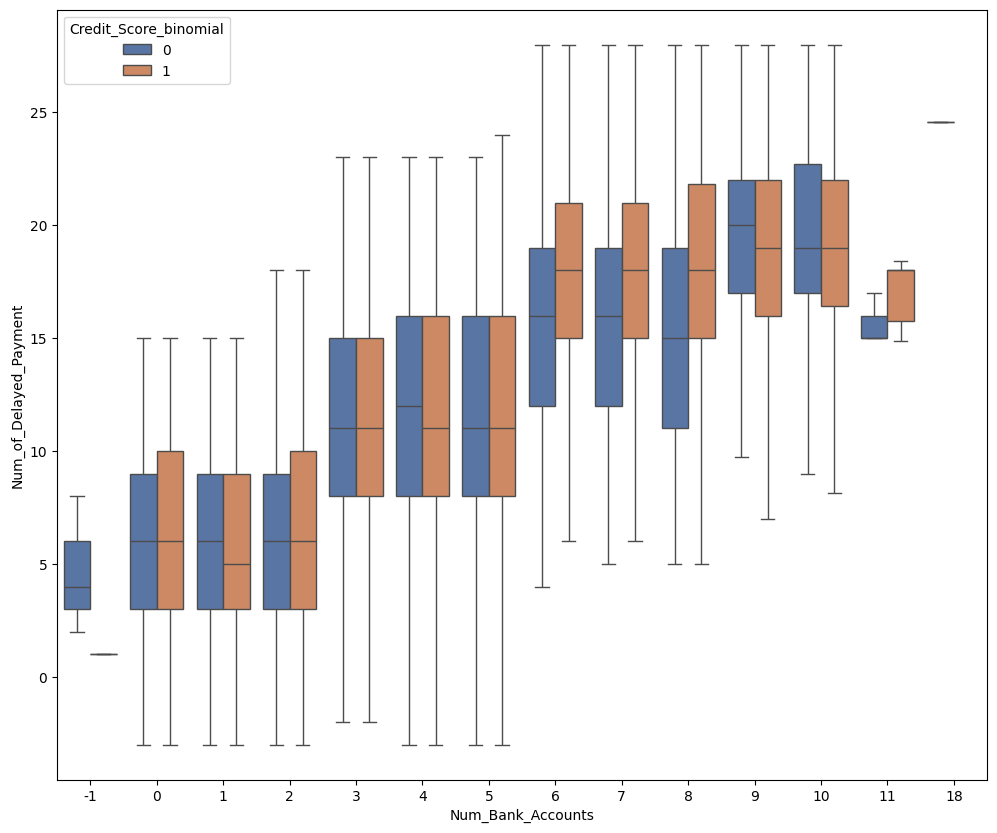

In [120]:
plt.figure(figsize=(12, 10))
sns.boxplot(
    df[df["Num_Bank_Accounts"] <= 20],
    x="Num_Bank_Accounts",
    y="Num_of_Delayed_Payment",
    showfliers=False,
    hue="Credit_Score_binomial",
)
plt.show()